In [1]:
# 1: Import
import sys
sys.path.append('../ml_pipeline')
from feature_engineering import *

print(" Feature engineering module loaded")

 Feature engineering module loaded


In [2]:
# 2: Run full pipeline
input_path = '../data/processed/insurance_claims_cleaned.csv'
output_path = '../data/processed/insurance_claims_engineered.csv'
scaler_path = '../models/scaler_v1.pkl'

df_engineered, scaler = engineer_features(input_path, output_path, scaler_path)

STARTING FEATURE ENGINEERING PIPELINE

 Loaded 15,420 records with 30 features

=== ENCODING ORDINAL FEATURES ===
✓ AgeOfVehicle: 8 categories → numeric scale
✓ VehiclePrice: 6 categories → numeric scale
✓ AgeOfPolicyHolder: 9 categories → numeric scale
✓ PastNumberOfClaims: 4 categories → numeric scale
✓ Days:Policy-Accident: 5 categories → numeric scale
✓ Days:Policy-Claim: 4 categories → numeric scale
✓ NumberOfSuppliments: 4 categories → numeric scale
✓ AddressChange-Claim: 5 categories → numeric scale
✓ NumberOfCars: 5 categories → numeric scale

=== CREATING DOMAIN-SPECIFIC FLAGS ===
✓ Created 11 domain-specific flags

=== CREATING INTERACTION FEATURES ===
✓ Created 5 interaction features

=== CREATING TEMPORAL FEATURES ===

=== ENCODING BINARY CATEGORICALS ===
✓ PoliceReportFiled: ['No', 'Yes'] → binary
✓ WitnessPresent: ['No', 'Yes'] → binary
✓ Fault: ['Third Party', 'Policy Holder'] → binary
✓ AgentType: ['Internal', 'External'] → binary
✓ AccidentArea: ['Rural', 'Urban'] → bi

In [3]:
# 3: Inspect engineered features
print("=== ENGINEERED DATASET SUMMARY ===\n")
print(f"Shape: {df_engineered.shape}")
print(f"Features: {len(df_engineered.columns) - 1}")
print(f"Samples: {len(df_engineered):,}")

=== ENGINEERED DATASET SUMMARY ===

Shape: (15420, 77)
Features: 76
Samples: 15,420


In [4]:
# 4: List all features by category
feature_cols = [col for col in df_engineered.columns if col != 'FraudFound_P']

print("=== FEATURE CATEGORIES ===\n")

# Ordinal encoded
ordinal = [col for col in feature_cols if '_encoded' in col]
print(f"Ordinal Encoded ({len(ordinal)}):")
for col in ordinal:
    print(f"  - {col}")

# Domain flags
flags = [col for col in feature_cols if any(x in col for x in ['no_', 'has_', 'is_', 'multiple_', 'many_', 'quick_', 'recent_', 'urban_', 'external_', 'policy_holder_'])]
print(f"\nDomain Flags ({len(flags)}):")
for col in flags:
    print(f"  - {col}")

# Interactions
interactions = [col for col in feature_cols if any(x in col for x in ['combo', 'interaction', '_claimer_', '_agent_'])]
print(f"\nInteraction Features ({len(interactions)}):")
for col in interactions:
    print(f"  - {col}")

# One-hot encoded
ohe = [col for col in feature_cols if any(col.startswith(x) for x in ['Make_', 'MaritalStatus_', 'PolicyType_', 'VehicleCategory_', 'BasePolicy_'])]
print(f"\nOne-Hot Encoded ({len(ohe)}):")
print(f"  Total: {len(ohe)} binary features from 5 categorical variables")

# Binary
binary = [col for col in feature_cols if '_binary' in col]
print(f"\nBinary Encoded ({len(binary)}):")
for col in binary:
    print(f"  - {col}")

# Numerical
numerical = [col for col in feature_cols if col in ['Age', 'Deductible', 'DriverRating', 'WeekOfMonth', 'WeekOfMonthClaimed']]
print(f"\nNumerical (Scaled) ({len(numerical)}):")
for col in numerical:
    print(f"  - {col}")

=== FEATURE CATEGORIES ===

Ordinal Encoded (9):
  - AgeOfVehicle_encoded
  - VehiclePrice_encoded
  - AgeOfPolicyHolder_encoded
  - PastNumberOfClaims_encoded
  - Days:Policy-Accident_encoded
  - Days:Policy-Claim_encoded
  - NumberOfSuppliments_encoded
  - AddressChange-Claim_encoded
  - NumberOfCars_encoded

Domain Flags (16):
  - no_police_report
  - no_witness
  - policy_holder_fault
  - external_agent
  - quick_claim
  - very_quick_claim_filing
  - has_past_claims
  - multiple_past_claims
  - recent_address_change
  - many_supplements
  - urban_accident
  - external_agent_holder_fault
  - quick_claim_no_police
  - urban_no_witness
  - is_weekend
  - is_end_of_year

Interaction Features (3):
  - high_risk_combo
  - external_agent_holder_fault
  - repeat_claimer_quick

One-Hot Encoded (33):
  Total: 33 binary features from 5 categorical variables

Binary Encoded (6):
  - PoliceReportFiled_binary
  - WitnessPresent_binary
  - Fault_binary
  - AgentType_binary
  - AccidentArea_binary

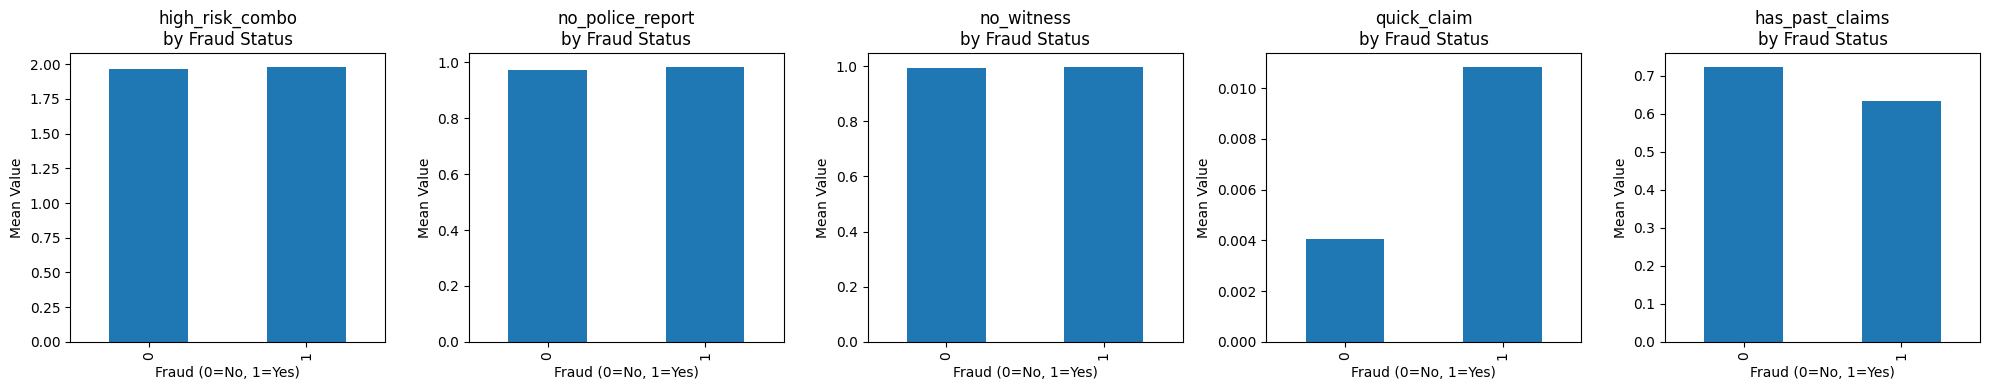

In [5]:
# 5: Check feature distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Sample some engineered features
sample_features = [
    'high_risk_combo',
    'no_police_report',
    'no_witness',
    'quick_claim',
    'has_past_claims'
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, col in enumerate(sample_features):
    df_engineered.groupby('FraudFound_P')[col].mean().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'{col}\nby Fraud Status')
    axes[idx].set_xlabel('Fraud (0=No, 1=Yes)')
    axes[idx].set_ylabel('Mean Value')

plt.tight_layout()
plt.show()

In [6]:
# 6: Correlation of new features with fraud
new_features = [col for col in df_engineered.columns 
                if col != 'FraudFound_P' and not col.startswith('Make_')]

# Calculate correlations with fraud
correlations = df_engineered[new_features + ['FraudFound_P']].corr()['FraudFound_P'].drop('FraudFound_P')
correlations = correlations.sort_values(ascending=False)

print("=== TOP 20 FEATURES CORRELATED WITH FRAUD ===\n")
print(correlations.head(20))

print("\n=== BOTTOM 10 (PROTECTIVE FACTORS) ===\n")
print(correlations.tail(10))

=== TOP 20 FEATURES CORRELATED WITH FRAUD ===

external_agent_holder_fault        0.133564
Fault_binary                       0.131389
policy_holder_fault                0.131389
PolicyType_Sport - Collision       0.050010
recent_address_change              0.046863
BasePolicy_Collision               0.043860
PolicyType_Utility - All Perils    0.038441
VehicleCategory_Utility            0.035815
VehiclePrice_encoded               0.031675
Sex_binary                         0.029953
PolicyType_Sedan - Collision       0.028302
AddressChange-Claim_encoded        0.027007
quick_claim_no_police              0.026232
quick_claim                        0.024042
external_agent                     0.022978
AgentType_binary                   0.022978
is_weekend                         0.019739
Deductible                         0.018322
DayOfWeek_numeric                  0.017452
high_risk_combo                    0.016702
Name: FraudFound_P, dtype: float64

=== BOTTOM 10 (PROTECTIVE FACTORS) ==

In [7]:
# Cell 7: Verify no data leakage
print("=== DATA QUALITY CHECKS ===\n")

# Check for nulls
print(f"Null values: {df_engineered.isnull().sum().sum()}")

# Check fraud distribution unchanged
print(f"\nFraud distribution:")
print(df_engineered['FraudFound_P'].value_counts())
print(f"Fraud rate: {df_engineered['FraudFound_P'].mean()*100:.2f}%")

# Verify all features are numeric
non_numeric = df_engineered.select_dtypes(exclude=['int64', 'float64', 'bool']).columns.tolist()
if 'FraudFound_P' in non_numeric:
    non_numeric.remove('FraudFound_P')
    
if non_numeric:
    print(f"\n⚠️ Warning: Non-numeric columns found: {non_numeric}")
else:
    print("\n✅ All features are numeric - ready for modeling!")

    print(df_engineered.isnull().sum()[df_engineered.isnull().sum() > 0])

=== DATA QUALITY CHECKS ===

Null values: 0

Fraud distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64
Fraud rate: 5.99%

✅ All features are numeric - ready for modeling!
Series([], dtype: int64)


In [8]:
# Load the original cleaned data (before feature engineering)
df_check = pd.read_csv('../data/processed/insurance_claims_cleaned.csv')

day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

print("Unmapped DayOfWeekClaimed values:", 
      set(df_check['DayOfWeekClaimed'].unique()) - set(day_map.keys()))

print("Unmapped MonthClaimed values:", 
      set(df_check['MonthClaimed'].unique()) - set(month_map.keys()))

Unmapped DayOfWeekClaimed values: {'0'}
Unmapped MonthClaimed values: {'0'}
